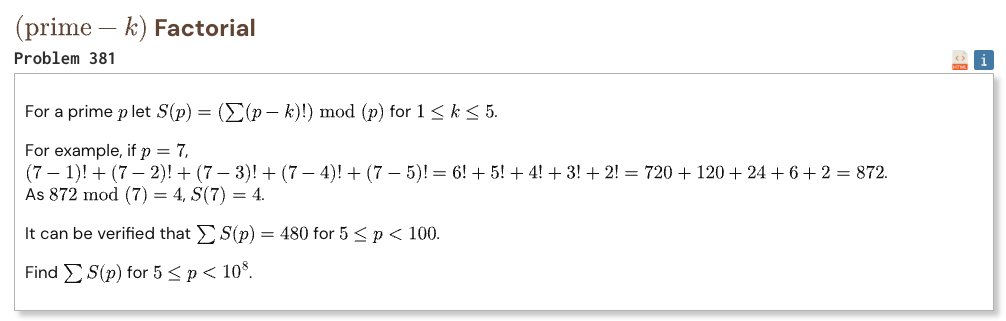

## Initial approach

* use wilson’s theorem to rewrite factorials close to p
* start with the fact that (p - 1)! is equal to -1 modulo p
* divide step by step to obtain the last five factorial values
* their sum simplifies to -3 / 8 modulo p
* choose a small multiplier so the division by 8 can be done with normal integers
* generate every prime below one hundred million with an odd only sieve
* calculate the simplified value for each prime and add the values together

In [1]:
from math import isqrt


def prime_sieve(limit):
    size = limit // 2
    sieve = bytearray(b"\x01") * size
    sieve[0] = 0

    for i in range(3, isqrt(limit - 1) + 1, 2):
        if sieve[i // 2]:
            start = i * i // 2
            count = ((size - 1 - start) // i) + 1
            sieve[start::i] = b"\x00" * count

    return sieve


def factorial_sum(p):
    multiplier = (3 * p) % 8
    return (multiplier * p - 3) // 8


def solve(limit):
    sieve = prime_sieve(limit)
    result = 0

    for p in range(5, limit, 2):
        if sieve[p // 2]:
            result += factorial_sum(p)

    return result

In [2]:
%%time
result = solve(100_000_000)
print("Result:", result)

Result: 139602943319822
CPU times: user 2.31 s, sys: 38.4 ms, total: 2.35 s
Wall time: 2.41 s
